# Task 5: Attention-Based GAN

This task enhances a Generative Adversarial Network (GAN) by incorporating an attention mechanism and text conditioning. The goal is to improve the Generator's ability to focus on relevant information from the input text while generating images.

## 1. Environment Setup

The required libraries and dependencies are installed and imported for dataset handling, model development, training, and visualization.

In [ ]:
import os

repo_path = "text-to-image-ai-project"

if not os.path.exists(repo_path):
    !git clone https://github.com/pjreddy-ml/text-to-image-ai-project.git
else:
    print("Repository already exists. Skipping clone.")

fatal: destination path 'text-to-image-ai-project' already exists and is not an empty directory.


In [ ]:
!pip install -q torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torchvision.utils as vutils

import matplotlib.pyplot as plt
import numpy as np
import os

## 3. Dataset Loading

The preprocessed landscape images are loaded using PyTorch's `ImageFolder` dataset and prepared using a `DataLoader` for batch-based training.

In [ ]:
# Image Transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load Dataset
dataset = datasets.ImageFolder(
    root="Task1_SD_Finetuning/dataset",
    transform=transform
)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

print("Number of Classes:", len(dataset.classes))
print("Classes:", dataset.classes)
print("Dataset Size:", len(dataset))

Number of Classes: 1
Classes: ['landscapes']
Dataset Size: 50


## 4. Dataset Visualization

A sample of the dataset is visualized to verify that the images have been loaded and preprocessed correctly.

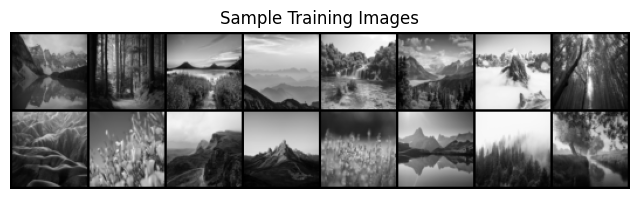

In [ ]:
# Display Sample Images
images, labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Sample Training Images")

plt.imshow(
    np.transpose(
        vutils.make_grid(images[:16], padding=2, normalize=True),
        (1, 2, 0)
    ),
    cmap="gray"
)

plt.show()

## 5. Attention Mechanism

An attention mechanism is introduced to help the Generator focus on important spatial features of the input representation. Self-attention allows different spatial locations within the feature map to interact with each other and capture long-range dependencies.

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()

        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)

        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        batch_size, C, width, height = x.size()

        query = self.query(x).view(batch_size, -1, width * height).permute(0, 2, 1)
        key = self.key(x).view(batch_size, -1, width * height)
        attention = self.softmax(torch.bmm(query, key))

        value = self.value(x).view(batch_size, -1, width * height)

        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(batch_size, C, width, height)

        out = self.gamma * out + x

        return out

## 6. CLIP Text Encoder

A pretrained CLIP tokenizer and text encoder are loaded to convert natural-language descriptions into numerical text embeddings. These embeddings provide textual information that can be used by the attention-based Generator during image generation.

In [ ]:
from transformers import CLIPTokenizer, CLIPTextModel

model_name = "openai/clip-vit-base-patch32"

tokenizer = CLIPTokenizer.from_pretrained(model_name)
text_encoder = CLIPTextModel.from_pretrained(model_name)

print("CLIP tokenizer and text encoder loaded successfully")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.post_layernorm.bias                               | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.l

CLIP tokenizer and text encoder loaded successfully


## 7. Generate Text Embeddings

A descriptive text prompt is tokenized and passed through the pretrained CLIP text encoder. The resulting embeddings contain a sequence of text features that are used to condition the Generator through cross-attention.

In [ ]:
# Generate CLIP text embeddings

text = "a beautiful landscape with mountains, trees and a blue sky"

inputs = tokenizer(
    text,
    padding="max_length",
    truncation=True,
    max_length=77,
    return_tensors="pt"
)

with torch.no_grad():
    text_embeddings = text_encoder(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    ).last_hidden_state

print("Text embedding shape:", text_embeddings.shape)

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Text embedding shape: torch.Size([1, 77, 512])


## 8. Cross-Attention Module

Cross-attention connects the generated image features with the CLIP text representation. Image features are used as queries, while the text embeddings provide keys and values, allowing the Generator to incorporate relevant information from the input description.

In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, image_dim=128, text_dim=512, num_heads=8):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=image_dim,
            num_heads=num_heads,
            kdim=text_dim,
            vdim=text_dim,
            batch_first=True
        )

        self.norm = nn.LayerNorm(image_dim)

    def forward(self, image_features, text_embeddings):
        # Image features: [B, 128, H, W]
        batch_size, channels, height, width = image_features.shape

        # Convert image features to tokens
        image_tokens = image_features.flatten(2).transpose(1, 2)

        # Cross-attention: image queries attend to text
        attended, _ = self.attention(
            query=image_tokens,
            key=text_embeddings,
            value=text_embeddings
        )

        # Residual connection + normalization
        image_tokens = self.norm(image_tokens + attended)

        # Convert back to image feature map
        image_features = image_tokens.transpose(1, 2).reshape(
            batch_size, channels, height, width
        )

        return image_features

## 9. Generator Architecture

The Generator transforms a latent noise vector into a 64×64 grayscale image. It combines the class embedding and CLIP text embedding with the latent representation, then progressively upsamples the feature maps through convolutional layers.

The model is designed to generate images conditioned on both the dataset class and the provided text representation.

In [ ]:
# Hyperparameters

latent_dim = 100
img_size = 64
num_classes = len(dataset.classes)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 50)

        self.project = nn.Sequential(
            nn.Linear(latent_dim + 50, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True)
        )

        self.deconv1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )

        self.deconv2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True)
        )

        # Self-Attention Layer
        self.attention = SelfAttention(128)
        self.cross_attention = CrossAttention(image_dim=128,
                                              text_dim=512,
                                              num_heads=8)

        self.deconv3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )

        self.output = nn.Sequential(
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, labels, text_embeddings):
        label = self.label_emb(labels)

        x = torch.cat((noise, label), dim=1)
        x = self.project(x)
        x = x.view(-1, 512, 4, 4)

        x = self.deconv1(x)
        x = self.deconv2(x)

        # Apply Self-Attention
        x = self.attention(x)
        x = self.cross_attention(x,text_embeddings)

        x = self.deconv3(x)

        return self.output(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, img_size * img_size)

        self.conv1 = nn.Sequential(
            nn.Conv2d(2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Self-Attention Layer
        self.attention = SelfAttention(128)

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label = self.label_emb(labels)
        label = label.view(-1, 1, img_size, img_size)

        x = torch.cat((img, label), dim=1)

        x = self.conv1(x)
        x = self.conv2(x)

        # Apply Self-Attention
        x = self.attention(x)

        x = self.conv3(x)
        x = self.conv4(x)

        return self.classifier(x)

## 10. Model Initialization

The Generator and Discriminator are initialized and moved to the available computation device. CUDA is used when a GPU is available; otherwise, the models run on the CPU.

The model architectures are printed to verify that both networks have been created correctly.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (label_emb): Embedding(1, 50)
  (project): Sequential(
    (0): Linear(in_features=150, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv1): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv2): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (attention): SelfAttention(
    (query): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
    (key): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
    (value): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (softmax): Softmax(dim=-1)
  )
  (cross_attention): Cro

## 10. Model Initialization

The Generator and Discriminator are initialized and moved to the available computation device. CUDA is used when a GPU is available; otherwise, the models run on the CPU.

The model architectures are printed to verify that both networks have been created correctly.

In [ ]:
text_embeddings = text_embeddings.to(device)

print("Text embeddings device:", text_embeddings.device)

Text embeddings device: cuda:0


## 12. GAN Training Setup

The Generator and Discriminator are trained using binary cross-entropy loss and Adam optimizers. The training loop alternates between updating the Discriminator with real and generated images, and updating the Generator to produce images that can successfully fool the Discriminator.

Training is performed for the specified number of epochs using the prepared dataset.

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 100

for epoch in range(epochs):

    for real_images, labels in tqdm(dataloader, leave=False):

        real_images = real_images.to(device)
        labels = labels.to(device)

        batch_size = real_images.size(0)

        real_targets = torch.ones(batch_size, 1, device=device) * 0.9
        fake_targets = torch.zeros(batch_size, 1, device=device)

        # Train Discriminator

        optimizer_D.zero_grad()

        output_real = discriminator(real_images, labels)
        loss_real = criterion(output_real, real_targets)

        noise = torch.randn(batch_size, latent_dim, device=device)
        batch_text_embeddings = text_embeddings.expand(real_images.size(0), -1, -1)
        fake_images = generator(noise, labels, batch_text_embeddings)

        output_fake = discriminator(fake_images.detach(), labels)
        loss_fake = criterion(output_fake, fake_targets)

        d_loss = (loss_real + loss_fake) / 2

        d_loss.backward()
        optimizer_D.step()

        # Train Generator

        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, latent_dim, device=device)
        batchg_text_embeddings = text_embeddings.expand(real_images.size(0), -1, -1)
        fake_images = generator(noise, labels, batch_text_embeddings)

        output = discriminator(fake_images, labels)

        g_loss = criterion(output, real_targets)

        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

print("Training Complete!")

Epoch [1/100] | D Loss: 0.3394 | G Loss: 3.3857


Epoch [2/100] | D Loss: 0.2273 | G Loss: 8.4851


Epoch [3/100] | D Loss: 0.1997 | G Loss: 5.6135


Epoch [4/100] | D Loss: 0.3042 | G Loss: 3.2891


Epoch [5/100] | D Loss: 0.2257 | G Loss: 3.8771


...

Epoch [96/100] | D Loss: 0.4351 | G Loss: 2.2380


Epoch [97/100] | D Loss: 0.2954 | G Loss: 2.5288


Epoch [98/100] | D Loss: 0.3133 | G Loss: 2.7167


Epoch [99/100] | D Loss: 0.1809 | G Loss: 2.6002


Epoch [100/100] | D Loss: 0.3181 | G Loss: 2.0784
Training Complete!


## 13. Test the Text-Conditioned Generator

The trained Generator is evaluated using a small batch of random noise and class labels. The corresponding CLIP text embeddings are expanded to match the batch size and passed to the Generator.

The resulting tensor shape is printed to verify that the Generator produces images with the expected dimensions.

In [ ]:
# Test the text-conditioned Generator

batch_size = 2

test_noise = torch.randn(batch_size, latent_dim, device=device)
test_labels = torch.zeros(batch_size, dtype=torch.long, device=device)

test_text_embeddings = text_embeddings.to(device).expand(
    batch_size, -1, -1
)

with torch.no_grad():
    test_output = generator(
        test_noise,
        test_labels,
        test_text_embeddings
    )

print("Generated image shape:", test_output.shape)

Generated image shape: torch.Size([2, 1, 64, 64])


## 14. Generate Sample Images

The trained Generator is used to produce sample images for visual evaluation. Random latent noise and class labels are provided as input, while the text embeddings condition the generation process.

The generated samples are converted into a displayable image format and visualized using Matplotlib.

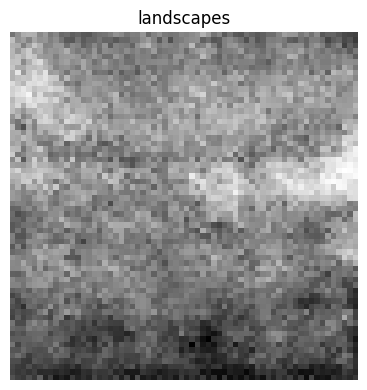

In [ ]:
import torch
import matplotlib.pyplot as plt

generator.eval()

num_samples = num_classes

noise = torch.randn(num_samples, latent_dim).to(device)
labels = torch.arange(num_classes).to(device)

with torch.no_grad():
    generated = generator(
        noise,
        labels,
        text_embeddings
        ).cpu()

fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))

if num_classes == 1:
    axes = [axes]

for i in range(num_classes):
    img = generated[i].squeeze()
    img = (img + 1) / 2  # Convert from [-1,1] to [0,1]

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(dataset.classes[i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 15. Final Task 5 Results

The trained attention-based GAN is used to generate the final set of sample images. Random latent vectors are combined with class labels and CLIP text embeddings to condition the generation process.

The generated images are converted to a displayable format and visualized using Matplotlib to evaluate the final output of the model.

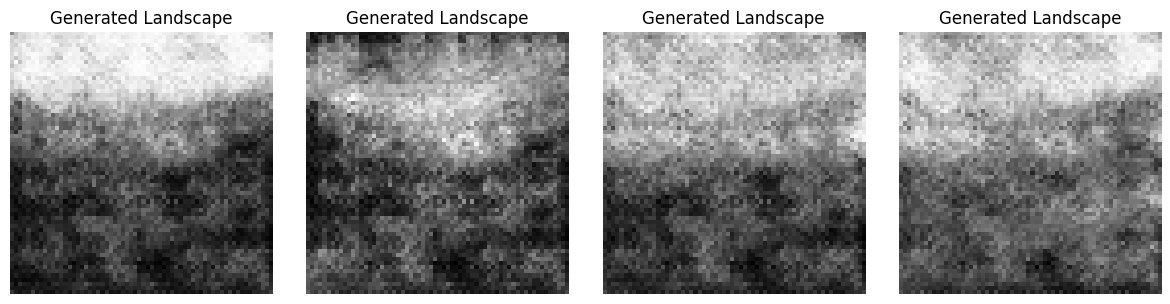

Final Task 5 result saved successfully.


In [ ]:
# Final Task 5 Attention-GAN Result

import torch
import matplotlib.pyplot as plt

generator.eval()

num_samples = 4

noise = torch.randn(num_samples, latent_dim, device=device)
labels = torch.zeros(num_samples, dtype=torch.long, device=device)

final_text_embeddings = text_embeddings.to(device).expand(
    num_samples, -1, -1
)

with torch.no_grad():
    final_images = generator(
        noise,
        labels,
        final_text_embeddings
    ).cpu()

fig, axes = plt.subplots(1, num_samples, figsize=(12, 3))

for i in range(num_samples):
    img = final_images[i].squeeze()
    img = (img + 1) / 2

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title("Generated Landscape")
    axes[i].axis("off")

plt.tight_layout()

plt.savefig(
    "/content/Task5_Attention_GAN_Result.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Final Task 5 result saved successfully.")